## Resources

# Titanic Survival Prediction Project

## Project Overview
This project focuses on predicting the survival of passengers on the Titanic using various machine learning techniques. The goal is to explore the dataset, preprocess the features, train different classification models, evaluate their performance, and save the best-performing model.

## Data Source
The dataset used is the well-known `titanic` dataset, often used for introductory machine learning tasks.

## Key Steps Performed:

1.  **Data Exploration and Visualization**: Initial analysis of the dataset, including survival rates by gender and passenger class, and age distribution of survivors vs. non-survivors.
2.  **Data Preprocessing**: Handling missing values, dropping irrelevant columns, and encoding categorical features using one-hot encoding.
3.  **Model Training & Evaluation (Logistic Regression)**: A Logistic Regression model was trained and evaluated to establish a baseline.
4.  **Model Training & Evaluation (Random Forest)**: A Random Forest classifier was implemented and assessed.
5.  **Tuned Model Training & Evaluation (Random Forest)**: The Random Forest model was further tuned with hyperparameters (`max_depth`, `min_samples_leaf`) to prevent overfitting and improve generalization. This tuned model achieved the best accuracy.
6.  **Model Saving**: The best-performing tuned Random Forest model (`tuned_rf`) was saved using `joblib` for future deployment or use.

## Models and Performance (Accuracy on Test Set):
*   **Logistic Regression**: ~79.78%
*   **Random Forest**: ~76.97%
*   **Tuned Random Forest**: ~81.46%

This notebook demonstrates a complete end-to-end machine learning workflow from data loading and cleaning to model training, evaluation, and saving.

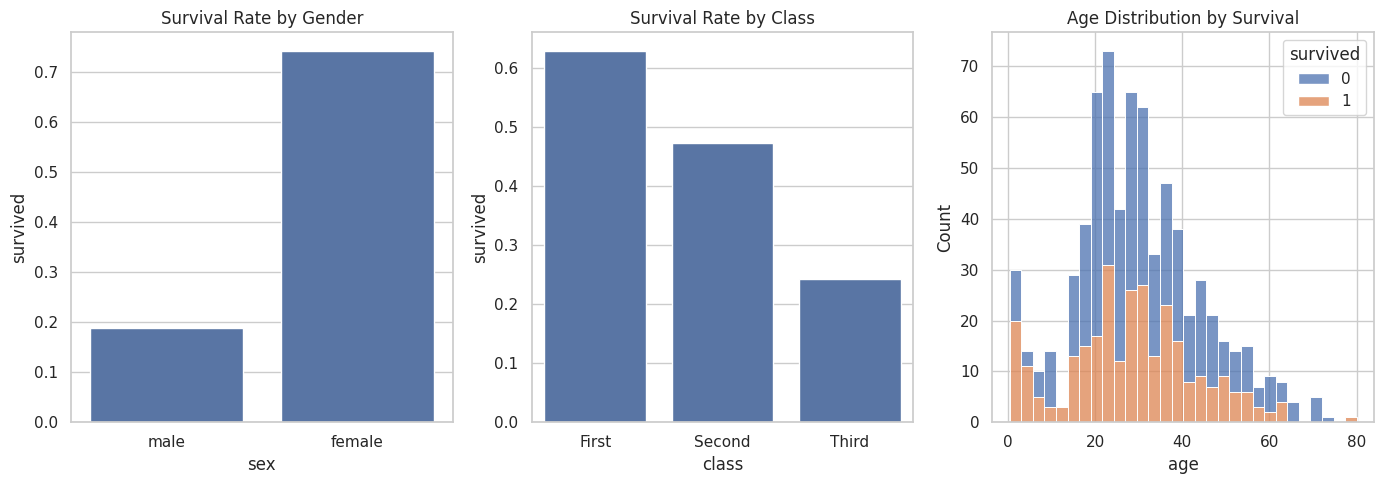

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fetch the dataset again just in case the runtime restarted
titanic_data = sns.load_dataset('titanic')

# Set up the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# 1. Conditional Probability of Survival given Gender
plt.subplot(1, 3, 1)
sns.barplot(x='sex', y='survived', data=titanic_data, errorbar=None)
plt.title('Survival Rate by Gender')

# 2. Conditional Probability of Survival given Passenger Class
plt.subplot(1, 3, 2)
sns.barplot(x='class', y='survived', data=titanic_data, errorbar=None)
plt.title('Survival Rate by Class')

# 3. Age Distribution of Survivors vs Non-Survivors
plt.subplot(1, 3, 3)
sns.histplot(data=titanic_data, x='age', hue='survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')

plt.tight_layout()
plt.show()

In [3]:
# 1. Drop redundant columns and columns with massive missing data
cols_to_drop = ['deck', 'alive', 'who', 'adult_male', 'class', 'embark_town']
titanic_clean = titanic_data.drop(columns=cols_to_drop)

# 2. Fill missing ages with the statistical median
titanic_clean['age'] = titanic_clean['age'].fillna(titanic_clean['age'].median())

# 3. Drop any tiny handful of remaining missing rows (like missing embark locations)
titanic_clean = titanic_clean.dropna()

# 4. Convert text ('sex', 'embarked') into numbers using One-Hot Encoding
# 'drop_first=True' prevents multicollinearity (e.g., if female is 0, model knows male is 1)
titanic_clean = pd.get_dummies(titanic_clean, columns=['sex', 'embarked'], drop_first=True)

# 5. Display the clean dataset and verify no missing values remain
print("\n--- Clean Dataset Preview ---")
print(titanic_clean.head())

print("\n--- Missing Values Left ---")
print(titanic_clean.isnull().sum())


--- Clean Dataset Preview ---
   survived  pclass   age  sibsp  parch     fare  alone  sex_male  embarked_Q  \
0         0       3  22.0      1      0   7.2500  False      True       False   
1         1       1  38.0      1      0  71.2833  False     False       False   
2         1       3  26.0      0      0   7.9250   True     False       False   
3         1       1  35.0      1      0  53.1000  False     False       False   
4         0       3  35.0      0      0   8.0500   True      True       False   

   embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  

--- Missing Values Left ---
survived      0
pclass        0
age           0
sibsp         0
parch         0
fare          0
alone         0
sex_male      0
embarked_Q    0
embarked_S    0
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Define Features (X) and Target (y)
X = titanic_clean.drop('survived', axis=1)
y = titanic_clean['survived']

# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Logistic Regression model
# We increase max_iter to 1000 to ensure the underlying mathematical solver converges cleanly
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Make predictions on the unseen test data
predictions = model.predict(X_test)

# 5. Evaluate the model's performance
accuracy = accuracy_score(y_test, predictions)
print(f"--- Model Accuracy ---")
print(f"{accuracy * 100:.2f}%\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, predictions))

--- Model Accuracy ---
79.78%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       109
           1       0.73      0.77      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



In [5]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model
# n_estimators=100 means we are building a "forest" of 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model on the exact same data we used before
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# 4. Evaluate the new model's performance
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"--- Random Forest Accuracy ---")
print(f"{rf_accuracy * 100:.2f}%\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, rf_predictions))

--- Random Forest Accuracy ---
76.97%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       109
           1       0.69      0.74      0.71        69

    accuracy                           0.77       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.77      0.77      0.77       178



In [6]:
# 1. Initialize a TUNED Random Forest
# We are adding constraints to stop the trees from memorizing the noise
tuned_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,          # Limit the tree depth
    min_samples_leaf=4,   # Require at least 4 passengers per final branch
    random_state=42
)

# 2. Train the tuned model on our training data
tuned_rf.fit(X_train, y_train)

# 3. Make predictions on the test set
tuned_predictions = tuned_rf.predict(X_test)

# 4. Evaluate the model's new performance
tuned_accuracy = accuracy_score(y_test, tuned_predictions)
print(f"--- Tuned Random Forest Accuracy ---")
print(f"{tuned_accuracy * 100:.2f}%\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, tuned_predictions))

--- Tuned Random Forest Accuracy ---
81.46%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       109
           1       0.80      0.70      0.74        69

    accuracy                           0.81       178
   macro avg       0.81      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178

